# Preprocessing Discover Graph text data

In [1]:
from neo4j import GraphDatabase, basic_auth
import pandas as pd
import numpy as np
import os
import json
import collections
import sklearn
import stellargraph as sg
import nltk
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
import networkx as nx
import pandas as pd
import numpy as np
import os
import tensorflow as tf


import stellargraph as sg
from stellargraph.mapper import FullBatchNodeGenerator
from stellargraph.layer import GAT

from tensorflow.keras import layers, optimizers, losses, metrics, Model
from sklearn import preprocessing, feature_extraction, model_selection
from stellargraph import datasets
from IPython.display import display, HTML
import matplotlib.pyplot as plt

nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/jpmc/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [3]:
driver = GraphDatabase.driver( "bolt://localhost:7687",  auth=basic_auth("neo4j", "nindoo123"))

# Creating StellarGraph

### Puxando Edges

In [4]:
pulling_query = """\
            MATCH (a)-->(b)
            WHERE EXISTS (a.label) AND EXISTS (b.label)
            RETURN ID(a) AS source, ID(b) AS target
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    edges_db = pd.DataFrame([dict(row) for row in result])
print(edges_db.shape)
edges_db.head()

(2852, 2)


,source,target
0,0,22
1,0,21
2,0,20
3,1,318
4,1,2


### puxando labels

In [5]:
pulling_query = """\
            MATCH (a)
            WHERE EXISTS (a.label)
            RETURN ID(a) AS source, a.label AS subject
            """
with driver.session() as sess:
    result = sess.run(pulling_query)
    label_db = pd.DataFrame([dict(row) for row in result])
labels = pd.Series(data =label_db['subject'].values, index = label_db['source'].values)
print(labels.shape)
labels.head()

(1068,)


0    Programming
1    Programming
2    Programming
3    Programming
4         Design
dtype: object

### Criando grafo

In [21]:
graph = sg.StellarGraph(edges =  edges_db)
print(graph.info())

StellarGraph: Undirected multigraph
 Nodes: 1060, Edges: 2852

 Node types:
  default: [1060]
    Features: none
    Edge types: default-default->default

 Edge types:
    default-default->default: [2852]
        Weights: all 1 (default)
        Features: none


In [52]:
# Retrieve node embeddings and corresponding subjects
node_ids = weighted_model.wv.index2word  # list of node IDs
weighted_node_embeddings = (
    weighted_model.wv.vectors
)  # numpy.ndarray of size number of nodes times embeddings dimensionality
# the gensim ordering may not match the StellarGraph one, so rearrange
int_ids = [int(node) for node in node_ids]
node_targets = labels.loc[int_ids].astype("category")

In [22]:

walk_length = 100  # maximum length of a random walk to use throughout this noteboo

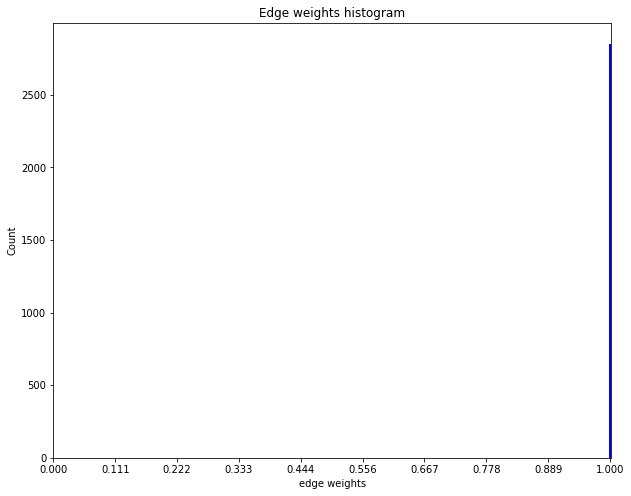

In [23]:

_, weights = graph.edges(include_edge_weight=True)

wt, cnt = np.unique(weights, return_counts=True)

plt.figure(figsize=(10, 8))
plt.bar(wt, cnt, width=0.005, color="b")
plt.title("Edge weights histogram")
plt.ylabel("Count")
plt.xlabel("edge weights")
plt.xticks(np.linspace(0, 1, 10))

plt.show()

In [26]:
rw = sg.data.BiasedRandomWalk(graph)
weighted_walks = rw.run(
    nodes=graph.nodes(),  # root nodes
    length=walk_length,  # maximum length of a random walk
    n=10,  # number of random walks per root node
    p=0.5,  # Defines (unormalised) probability, 1/p, of returning to source node
    q=2.0,  # Defines (unormalised) probability, 1/q, for moving away from source node
    weighted=True,  # for weighted random walks
    seed=42,  # random seed fixed for reproducibility
)
print("Number of random walks: {}".format(len(weighted_walks)))

Number of random walks: 10600


In [33]:
string_walks = []
for walk in weighted_walks:
    swalk = []
    for node in walk:
        swalk.append(str(node))
    string_walks.append(swalk)

['0', '844', '0', '1107', '0', '766', '0', '1147', '652', '1383', '168', '20', '953', '1073', '952', '1073', '952', '20', '220', '85', '220', '85', '998', '7', '998', '1000', '998', '1110', '998', '1000', '998', '1000', '998', '85', '120', '864', '689', '120', '79', '120', '79', '1369', '79', '76', '822', '76', '107', '661', '85', '998', '7', '657', '302', '42', '69', '71', '58', '1140', '1155', '1141', '1155', '134', '1155', '134', '1155', '134', '1155', '40', '1346', '40', '1346', '40', '1155', '1140', '1141', '1140', '1141', '1155', '58', '244', '247', '244', '247', '244', '58', '102', '1358', '35', '1060', '35', '99', '181', '1339', '56', '798', '20', '1122', '685', '20', '36']


In [37]:
from gensim.models import Word2Vec
weighted_model = Word2Vec(
    string_walks, size=128, window=5, min_count=0, sg=1, workers=1, iter=1
)

In [39]:
emb = weighted_model.wv["397"]
emb.shape

(128,)

### Embeddings

In [53]:
print(node_targets)

102              ML
20      Programming
35               ML
99               ML
73               ML
           ...     
628              ML
623     Programming
1195             AI
961     Programming
1366         Design
Length: 1060, dtype: category
Categories (6, object): [AI, Design, Education, ML, Programming, Society]


In [54]:
tsne = TSNE(n_components=2, random_state=42)
weighted_node_embeddings_2d = tsne.fit_transform(weighted_node_embeddings)

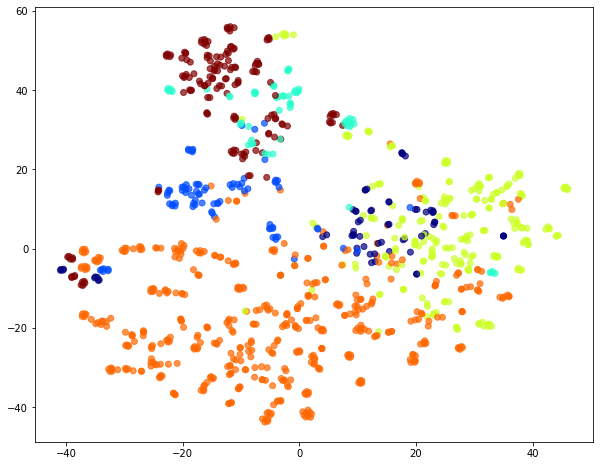

In [56]:

# draw the points
alpha = 0.7

plt.figure(figsize=(10, 8))
plt.scatter(
    weighted_node_embeddings_2d[:, 0],
    weighted_node_embeddings_2d[:, 1],
    c=node_targets.cat.codes,
    cmap="jet",
    alpha=0.7,
)
plt.show()

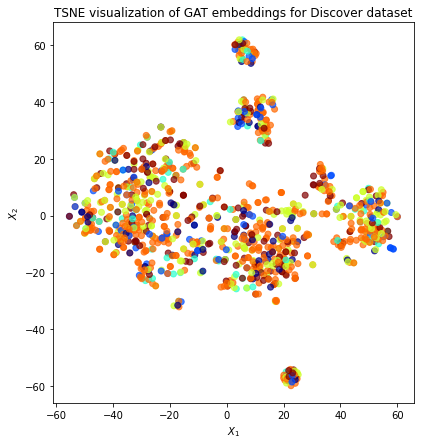

In [427]:
alpha = 0.7

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    emb_transformed[0],
    emb_transformed[1],
    c=emb_transformed["label"].astype("category"),
    cmap="jet",
    alpha=alpha,
)
ax.set(aspect="equal", xlabel="$X_1$", ylabel="$X_2$")
plt.title(
    "{} visualization of GAT embeddings for Discover dataset".format(transform.__name__)
)
plt.show()